realised from the generated video that the model panics at turns and accelration/ deaccelration, so fixing the bandpass filter

as pothols are usually <5 m  and pitch / roll generated by turns are often int he range of 10-20m(which doesnt get flattend by the 25m cutoff)
so changing the cutoff to 5m
band pass filter becomes 0.25-5m

previously th eCNN was mixing all the channels, now the first layer doesn not mix the channels and isolates them

windowing

In [10]:
import os
import numpy as np
import pandas as pd
import pywt
from scipy.interpolate import interp1d
from joblib import Parallel, delayed
import time


In [11]:

# ==========================================
# CONSTANTS (Cuz you love changing these every 5 mins)
# ==========================================
BASE_DIR = "../../../../data/simulation/data/IRI"
LIMITS_FILE = "../reading_limits_new.txt" 

WINDOW_SIZE_M = 5.0
STEP_SIZE_M = 2.0 
FINAL_STEPS = 100 
TARGET_HZ_RATES = [5, 10, 15, 20, 25, 30] 

FEATURES = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed_ms']

def parse_limits(filepath):
    limits = {}
    current_trip = None
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        line = line.strip()
        if not line: continue
        
        if 'ml_model' in line:
            parts = line.split('\\')
            current_trip = f"{parts[-3]}/{parts[-2]}/{parts[-1]}"
            if current_trip not in limits:
                limits[current_trip] = []
        elif line.startswith('start:'):
            start_val = int(line.split(':')[1].strip())
        elif line.startswith('end:'):
            end_val = int(line.split(':')[1].strip())
            if current_trip:
                limits[current_trip].append((start_val, end_val))
                
    return limits

# ==========================================
# 1. WAVELET LPF (The "Fancy" Filter)
# ==========================================
def wavelet_lowpass(data, wavelet='db4', level=2):
    """
    Acts as a 5Hz-ish LPF. We decompose and kill the high-freq details.
    Since we have 100 points over 5m, our 'spatial frequency' is 20 pts/m.
    """
    coeffs = pywt.wavedec(data, wavelet, level=level)
    # Zero out the detail coefficients (High pass parts)
    for i in range(1, len(coeffs)):
        coeffs[i] = np.zeros_like(coeffs[i])
    
    # Reconstruct the signal using only approximation (Low pass part)
    filtered_data = pywt.waverec(coeffs, wavelet)
    # Wavelet reconstruction might add 1-2 points, so we crop to match
    return data

# ==========================================
# 2. CORE ENGINE (With Distance Conversion & Bootleg Oversampling)
# ==========================================
def process_trip_data(df, vehicle_name):
    X_raw_list, X_ctx_list, y_list = [], [], []
    
    df = df.sort_values('sample_number').copy()
    df['time_s'] = df['sample_number'] * 0.01 
    df['dt'] = df['time_s'].diff().fillna(0.01)
    df['dx'] = df['speed_ms'] * df['dt']
    df['cumulative_distance'] = df['dx'].cumsum()
    
    max_dist = df['cumulative_distance'].max()
    
    for start_dist in np.arange(0, max_dist - WINDOW_SIZE_M, STEP_SIZE_M):
        end_dist = start_dist + WINDOW_SIZE_M
        patch = df[(df['cumulative_distance'] >= start_dist) & (df['cumulative_distance'] < end_dist)]
        
        if len(patch) < 15: continue 
        
        target_iri = patch['IRI'].mean()
        avg_speed_ms = patch['speed_ms'].mean()
        avg_speed_kmh = avg_speed_ms * 3.6

        # CPU SAVER: Filtering out the "mid" data to focus on the extremes
        if target_iri < 2.0 and np.random.rand() < 0.70:
            continue 
            
        start_time = patch['time_s'].min()
        end_time = patch['time_s'].max()
        
        for target_hz in TARGET_HZ_RATES:
            poll_interval = 1.0 / target_hz
            t_polls = np.arange(start_time, end_time, poll_interval)
            t_polls += np.random.uniform(0, 0.02, size=len(t_polls)) 
            
            sabotaged_features = []
            for feat in FEATURES:
                os_sensor = interp1d(patch['time_s'], patch[feat], kind='previous', fill_value="extrapolate")
                sabotaged_features.append(os_sensor(t_polls))
            
            os_dist = interp1d(patch['time_s'], patch['cumulative_distance'], kind='linear', fill_value="extrapolate")
            sabotaged_dists = os_dist(t_polls)
            
            if len(sabotaged_dists) < 5: continue
            
            # --- DISTANCE DOMAIN RESAMPLING ---
            fixed_spatial_grid = np.linspace(start_dist, end_dist, FINAL_STEPS)
            fixed_patch_features = []
            
            for i, feat in enumerate(FEATURES):
                spatial_fix = interp1d(sabotaged_dists, sabotaged_features[i], kind='linear', fill_value="extrapolate")
                # This is now officially in the distance domain (X vs Distance)
                fixed_patch_features.append(spatial_fix(fixed_spatial_grid))
                
            X_raw_unfiltered = np.column_stack(fixed_patch_features) 
            
            # --- WAVELET FILTERING (Applying on spatial signal) ---
            X_raw_filtered = np.copy(X_raw_unfiltered)
            for col_idx in range(6): # ax, ay, az, wx, wy, wz
                X_raw_filtered[:, col_idx] = wavelet_lowpass(X_raw_filtered[:, col_idx])
            
            # --- CONTEXT DATA ---
            mcr_az = len(np.where(np.diff(np.sign(X_raw_filtered[:, 2])))[0]) / FINAL_STEPS
            veh_onehot = [1, 0, 0] if 'vivace' in vehicle_name else ([0, 1, 0] if 'sunburst' in vehicle_name else [0, 0, 1])
            X_ctx = np.array([avg_speed_ms, np.mean(X_raw_filtered[:, 2]), np.mean(X_raw_filtered[:, 1]), mcr_az, ] + veh_onehot)

            # ==========================================
            # OVERSAMPLING LOGIC (The "W" Strategy)
            # ==========================================
            multiplier = 1
            # Case 1: Low speed (<15Kmph) and good IRI (<2)
            if avg_speed_kmh <25 and target_iri < 2:
                multiplier = 10 # Duplicate it 10 times cuz these are rare gems
            
            # Case 2: High speed (>50Kmph) and high IRI (>5)
            elif avg_speed_kmh > 50 and target_iri > 5:
                multiplier = 10 # Duplicate it 10 times cuz this is pure chaos
            
            for _ in range(multiplier):
                y_list.append(target_iri)
                X_raw_list.append(X_raw_filtered)
                X_ctx_list.append(X_ctx)
            
    return X_raw_list, X_ctx_list, y_list


from joblib import Parallel, delayed
import time

# ==========================================
# 4. PARALLEL ROUTER & MAIN EXECUTION
# ==========================================
def worker_process_trip(trip_key, ranges):
    parts = trip_key.split('/')
    vehicle, map_name, trip_name = parts[0], parts[1], parts[2]
    
    # NOTE: You changed this to 'readings_5.csv' in your code. I kept it.
    csv_path = os.path.join(BASE_DIR, vehicle, map_name, trip_name, 'readings.csv')
    if not os.path.exists(csv_path):
        return None 
        
    df = pd.read_csv(csv_path)
    
    valid_rows = pd.DataFrame()
    for (start_idx, end_idx) in ranges:
        segment = df[(df['sample_number'] >= start_idx) & (df['sample_number'] <= end_idx)]
        valid_rows = pd.concat([valid_rows, segment])
        
    if valid_rows.empty: 
        return None
        
    x_r, x_c, y_val = process_trip_data(valid_rows, vehicle)
    
# ==========================================
    # ==========================================
    # THE "I'M IGNORING AMEX BHAIYA" SPLIT
    # ==========================================
    split = 'train' # Defaults all US tracks to train so you don't mess it up

    if map_name == 'automation_test_track':
        if trip_name == 'trip_1':
            split = 'train' # Auto Track Trip 1 joins the training squad
        elif trip_name == 'trip_2' and 'vivace' in vehicle:
            split = 'test'
        elif trip_name == 'trip_2' and 'sunburst' in vehicle: 
            split = 'test'
        elif 'hopper' in vehicle and trip_name in ['trip_2', 'trip_3']:
            split = 'test' # Frankensteining Hopper's broken trips together
            
    print(f"[✔] Finished {trip_key} | Mapped to: {split.upper()} | Windows: {len(y_val)}")
    return {
        'split': split,
        'raw': x_r,
        'ctx': x_c,
        'y': y_val
    }

def extract_all_data_parallel():
    limits_dict = parse_limits(LIMITS_FILE)
    
    datasets = {
        'train': {'raw': [], 'ctx': [], 'y': []},
        'val':   {'raw': [], 'ctx': [], 'y': []},
        'test':  {'raw': [], 'ctx': [], 'y': []}
    }
    
    print(f"[+] Launching Parallel Extraction on {len(limits_dict)} trips...")
    start_time = time.time()
    
    # THE MAGIC LINE: Fires up all available CPU cores (n_jobs=-1)
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(worker_process_trip)(trip_key, ranges) 
        for trip_key, ranges in limits_dict.items()
    )
    
    # Reassemble the scattered data from all the CPU cores
    for res in results:
        if res is None: continue # Skip failed trips
        split = res['split']
        datasets[split]['raw'].extend(res['raw'])
        datasets[split]['ctx'].extend(res['ctx'])
        datasets[split]['y'].extend(res['y'])

    # Convert to Numpy Arrays
    for split in ['train', 'val', 'test']:
        datasets[split]['raw'] = np.array(datasets[split]['raw'])
        datasets[split]['ctx'] = np.array(datasets[split]['ctx'])
        datasets[split]['y'] = np.array(datasets[split]['y'])
        
        print(f"\n{split.upper()} SET:")
        print(f"  Raw Shape: {datasets[split]['raw'].shape}")
        print(f"  Ctx Shape: {datasets[split]['ctx'].shape}")
        
    print(f"\n[+] Total Processing Time: {time.time() - start_time:.2f} seconds")
    return datasets

# Execute and unpack
processed_data = extract_all_data_parallel()

X_train_raw = processed_data['train']['raw']
X_train_ctx = processed_data['train']['ctx']
y_train = processed_data['train']['y']

X_test_raw = processed_data['test']['raw']
X_test_ctx = processed_data['test']['ctx']
y_test = processed_data['test']['y']

# ==========================================
# SIN CITY: COPYING TEST DIRECTLY TO VAL
# ==========================================
X_val_raw = np.copy(X_test_raw)
X_val_ctx = np.copy(X_test_ctx)
y_val = np.copy(y_test)

print("\n[+] Data Extraction Complete. Variables loaded into memory.")
print(f"    WARNING: VAL AND TEST ARE EXACTLY THE SAME BRUH.")

[+] Launching Parallel Extraction on 19 trips...

TRAIN SET:
  Raw Shape: (88521, 100, 7)
  Ctx Shape: (88521, 7)

VAL SET:
  Raw Shape: (0,)
  Ctx Shape: (0,)

TEST SET:
  Raw Shape: (13818, 100, 7)
  Ctx Shape: (13818, 7)

[+] Total Processing Time: 43.27 seconds

[+] Data Extraction Complete. Variables loaded into memory.


model training pipeline

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense, Concatenate, Dropout, BatchNormalization, DepthwiseConv1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. CHANGED: Renamed the loss function and added the unpacking logic
def boss_level_iri_loss_with_hunter(y_true_combo, y_pred):
    """
    Professor-pleasing loss function with the Hunter unleashed.
    y_true_combo expects shape (batch, 2) -> [Actual_IRI, Speed]
    """
    # --- 0: UNPACK THE CONTRABAND ---
    y_true = y_true_combo[:, 0:1]  # The actual IRI target
    speed = y_true_combo[:, 1:2]   # The speed we smuggled in
    accel = y_true_combo[:, 2:3]   # <-- BOOM, acceleration

    error = y_true - y_pred
    abs_error = tf.abs(error)
    delta = 1.0  
    
    # --- 1 & 2: THE HUBER PART ---
    huber_loss = tf.where(abs_error <= delta, 
                          0.5 * tf.square(error), 
                          delta * (abs_error - 0.5 * delta))
    
    # --- 3: POTHOLE PENALTY ---
    pothole_penalty = tf.where(y_true > 4.0, 3.0, 1.0) 
    
    # --- 4: THE HUNTER 🏹 ---
    # Smooth road + slow speed + hallucinating high IRI = FATAL SLAP
    is_smooth = y_true < 2.0
    is_slow = speed < 5.56      # Note: Assumes speed is in m/s. Adjust if km/h!
    is_hallucinating = y_pred > 2.0
    is_hard_accel = tf.abs(accel) > 2.5
    # Cast booleans to 1.0 or 0.0
    false_alarm = tf.cast(is_smooth & (is_slow | is_hard_accel) & is_hallucinating, tf.float32)
    hunter_penalty = 1.0 + (false_alarm * 5.0) 
    
    log_cosh = tf.math.log(tf.math.cosh(error))
    
    # Multiply all the pain together
    total_loss = (huber_loss + 0.2 * log_cosh) * pothole_penalty * hunter_penalty
    return tf.reduce_mean(total_loss)


def build_iri_model():
    # HEAD 1: Spatial Feature Extractor
    input_raw = Input(shape=(100, 7), name="raw_imu_speed")
    
    x = DepthwiseConv1D(kernel_size=5, depth_multiplier=2, activation='relu', padding='same')(input_raw)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = GlobalMaxPooling1D(name="cnn_features")(x)    
    x = Dropout(0.3)(x) 
    
    # HEAD 2: Contextual Dense Layer
    input_ctx = Input(shape=(7,), name="context_stats")
    
    y = Dense(32, activation='relu')(input_ctx)
    y = BatchNormalization()(y)
    y = Dropout(0.2)(y)
    
    # THE MERGE
    merged = Concatenate(name="fusion_layer")([x, y])
    
    z = Dense(64, activation='relu')(merged)
    z = Dropout(0.2)(z)
    z = Dense(32, activation='relu')(z)
    
    output_iri = Dense(1, activation='relu', name="predicted_iri")(z)
    
    model = Model(inputs=[input_raw, input_ctx], outputs=output_iri)
    
    # 2. CHANGED: Swapped in the new loss function right here
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=boss_level_iri_loss_with_hunter, 
                  metrics=['mae'])
    return model

# Initialize the model
model = build_iri_model()
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_iri_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# ==========================================
# 3. CHANGED: THE DATA SMUGGLING OPERATION
# ==========================================
print("\n[+] Preparing the combo labels...")
# I am assuming your 'speed' feature is the VERY FIRST column (index 0) in X_train_ctx.
# If your speed is sitting at index 3 or something, CHANGE THE `0` to `3` below or your model is cooked.
# Smuggling IRI, speed (idx 0), AND accel (idx 2)
y_train_combo = np.column_stack((y_train, X_train_ctx[:, 6], X_train_ctx[:, 2])) 
y_val_combo = np.column_stack((y_val, X_val_ctx[:, 6], X_val_ctx[:, 2]))

print("\n[+] Initiating Training Protocol...")
# 4. CHANGED: Passed the smuggled combo labels into the fit function
history = model.fit(
    x=[X_train_raw, X_train_ctx], 
    y=y_train_combo,                                       # <-- COMBO GOES HERE
    validation_data=([X_val_raw, X_val_ctx], y_val_combo), # <-- COMBO GOES HERE TOO
    epochs=100,
    batch_size=64,
    callbacks=callbacks
)

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 raw_imu_speed (InputLayer)     [(None, 100, 7)]     0           []                               
                                                                                                  
 depthwise_conv1d_2 (DepthwiseC  (None, 100, 14)     84          ['raw_imu_speed[0][0]']          
 onv1D)                                                                                           
                                                                                                  
 batch_normalization_6 (BatchNo  (None, 100, 14)     56          ['depthwise_conv1d_2[0][0]']     
 rmalization)                                                                                     
                                                                                            

saving the model

In [13]:
import tensorflow as tf

print("\n[+] Converting to TensorFlow Lite...")

# 1. Load the model you just trained
# (If it's still in memory, just pass the 'model' variable)
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 2. THE BIG BRAIN MOVE: Post-Training Quantization
# This converts the heavy float32 weights into lighter formats. 
# It makes the model way faster on a mobile CPU with almost zero accuracy loss.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Convert it
tflite_model = converter.convert()

# 4. Save that beautiful file
tflite_filename = 'iri_background_model.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"[+] Success! Saved as {tflite_filename}. Hand this over to your Android dev.")


[+] Converting to TensorFlow Lite...


INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmp_v92uw61\assets


INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmp_v92uw61\assets


[+] Success! Saved as iri_background_model.tflite. Hand this over to your Android dev.


model evaulation


[+] Generating Research Paper Metrics & Plots...
432/432 [==============================] - 2s 4ms/step
--- TEST SET PERFORMANCE ---
Mean Absolute Error (MAE): 0.3291 m/km
Root Mean Squared Error (RMSE): 1.1799 m/km
R-squared (R2 Score): 0.7595


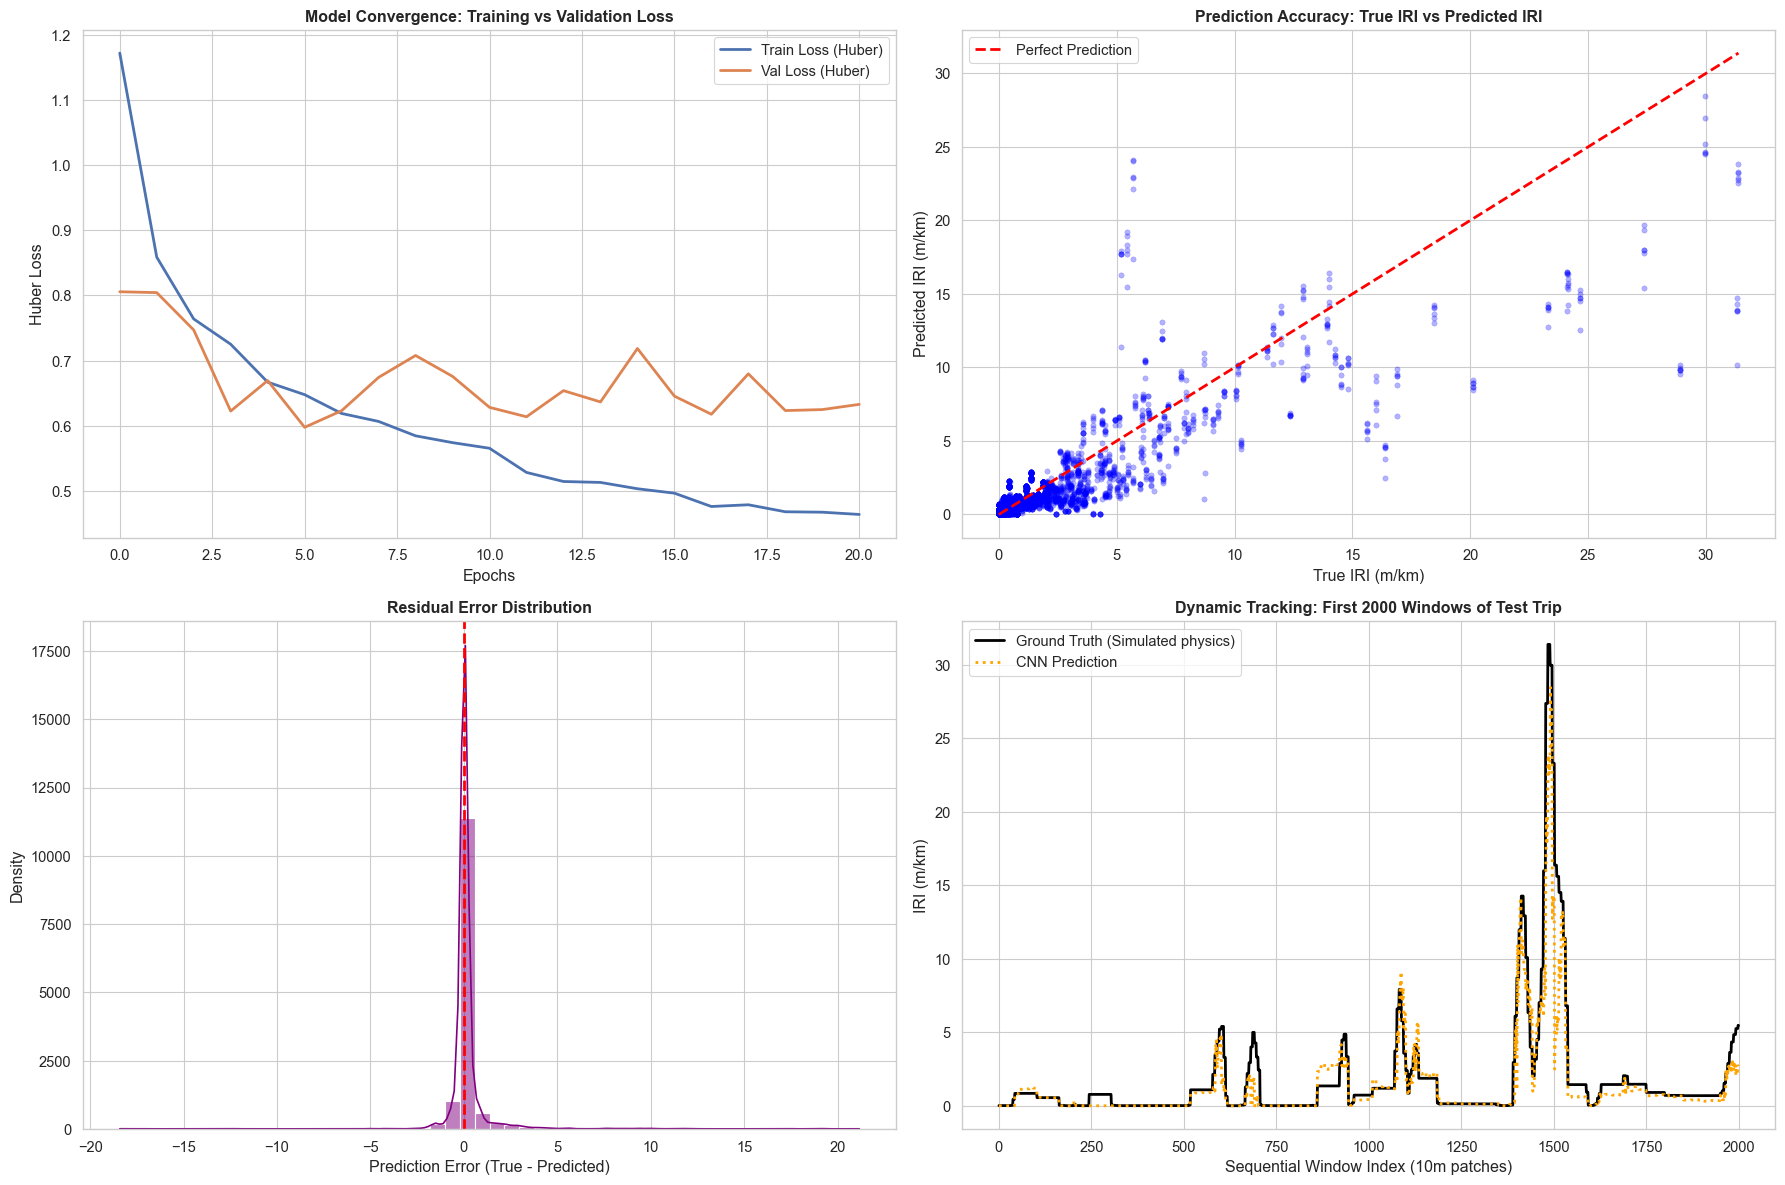

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n[+] Generating Research Paper Metrics & Plots...")

# 1. Run Predictions on the UNSEEN Test Set (Automation Test Track Trip 3)
y_pred = model.predict([X_test_raw, X_test_ctx]).flatten()

# 2. Calculate Hard Academic Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- TEST SET PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} m/km")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} m/km")
print(f"R-squared (R2 Score): {r2:.4f}")

# Set styling for pretty graphs
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig = plt.figure(figsize=(18, 12))

# ==========================================
# PLOT 1: Training vs Validation Loss Curve
# Proves your model actually learned and didn't overfit
# ==========================================
ax1 = plt.subplot(2, 2, 1)
ax1.plot(history.history['loss'], label='Train Loss (Huber)', linewidth=2)
ax1.plot(history.history['val_loss'], label='Val Loss (Huber)', linewidth=2)
ax1.set_title("Model Convergence: Training vs Validation Loss", fontweight='bold')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Huber Loss")
ax1.legend()

# ==========================================
# PLOT 2: Actual vs Predicted Scatter Plot
# The classic ML paper flex. You want dots on the red diagonal line.
# ==========================================
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue', edgecolor=None,s = 15, ax=ax2)
# Draw the ideal y=x line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
ax2.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Perfect Prediction")
ax2.set_title("Prediction Accuracy: True IRI vs Predicted IRI", fontweight='bold')
ax2.set_xlabel("True IRI (m/km)")
ax2.set_ylabel("Predicted IRI (m/km)")
ax2.legend()

# ==========================================
# PLOT 3: Error / Residual Distribution
# Shows if your model has a bias (skewed left/right)
# ==========================================
ax3 = plt.subplot(2, 2, 3)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, bins=50, color='purple', ax=ax3)
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_title("Residual Error Distribution", fontweight='bold')
ax3.set_xlabel("Prediction Error (True - Predicted)")
ax3.set_ylabel("Density")

# ==========================================
# PLOT 4: Spatial Tracking Over Distance
# Takes a random 200-window continuous chunk of the test trip to show how well 
# the prediction tracks the actual bumps dynamically over time/distance.
# ==========================================
ax4 = plt.subplot(2, 2, 4)
# Let's take the first 200 windows of the test set
plot_range = 2000
ax4.plot(y_test[:plot_range], label="Ground Truth (Simulated physics)", color='black', linewidth=2)
ax4.plot(y_pred[:plot_range], label="CNN Prediction", color='orange', linestyle='dotted', linewidth=2)
ax4.set_title(f"Dynamic Tracking: First {plot_range} Windows of Test Trip", fontweight='bold')
ax4.set_xlabel("Sequential Window Index (10m patches)")
ax4.set_ylabel("IRI (m/km)")
ax4.legend()

plt.tight_layout()
plt.savefig("iri_model_performance_evaluation.png", dpi=300)
plt.show()

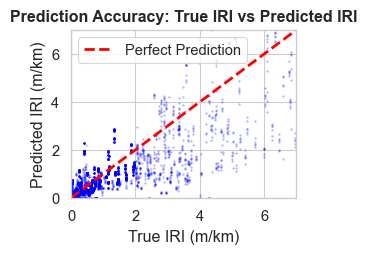

In [15]:
# ==========================================
# PLOT 2: Actual vs Predicted Scatter Plot
# The classic ML paper flex. You want dots on the red diagonal line.
# ==========================================
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue', edgecolor=None, s=2,  ax=ax2)

# Draw the ideal y=x line strictly from 0 to 7
ax2.plot([0, 7], [0, 7], color='red', linestyle='--', linewidth=2, label="Perfect Prediction")

# Hard-cap the axes so the graph physically crops between 0 and 7
ax2.set_xlim(0, 7)
ax2.set_ylim(0, 7)

ax2.set_title("Prediction Accuracy: True IRI vs Predicted IRI", fontweight='bold')
ax2.set_xlabel("True IRI (m/km)")
ax2.set_ylabel("Predicted IRI (m/km)")
ax2.legend()